# 머신비전 - 커넥터 형태 분류 (4-Class Classification)

| 클래스 | 설명 |
|--------|------|
| mug | Mug 타입 |
| straight | Straight 타입 |
| taper_smooth | Taper Smooth 타입 |
| taper_step | Taper Step 타입 |

In [2]:
pip install torch

^C
Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
print("PyTorch 버전:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))
    print("CUDA 버전:", torch.version.cuda)

c:\miniforge3\envs\vision_project\lib\site-packages\torch\_subclasses\functional_tensor.py:368: UserWarning: Failed to initialize NumPy: No module named 'numpy' (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:84.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


PyTorch 버전: 2.14.0+cpu
CUDA 사용 가능: False


  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp310-cp310-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 1.0/124.1 MB 10.1 MB/s eta 0:00:13
   - -------------------------------------- 3.9/124.1 MB 12.4 MB/s eta 0:00:10
   - -------------------------------------- 6.0/124.1 MB 11.5 MB/s eta 0:00:11
   -- ------------------------------------- 8.1/124.1 MB 11.7 MB/s eta 0:00:10
   --- ------------------------------------ 10.5/124.1 MB 11.9 MB/s eta 0:00:10
   ---- ----------------------------------- 13.9/124.1 MB 12.3 MB/s eta 0:00:09
   ----- ---------------------------------- 16.3/124.1 MB 12.3 MB/s eta 0:00:09
   ------ --------------------------------- 19.1/124.1 MB 12.3 MB/s eta 0:00:09
   ------ --------------------------------- 21.5/124.1 MB 12.2 MB/s eta 0:00:09
   ------- -------------------------------- 24.4/124.1 MB 12.3 MB/s eta 0:

In [4]:
import sys
!{sys.executable} -m pip uninstall torch torchvision -y

Found existing installation: torch 2.14.0
Uninstalling torch-2.14.0:
  Successfully uninstalled torch-2.14.0


You can safely remove it manually.


In [5]:
import sys
!{sys.executable} -m pip install numpy torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB 3.6 MB/s eta 0:12:02
   ---------------------------------------- 0.0/2.6 GB 4.2 MB/s eta 0:10:20
   ---------------------------------------- 0.0/2.6 GB 4.5 MB/s eta 0:09:37
   ---------------------------------------- 0.0/2.6 GB 4.8 MB/s eta 0:09:03
   ---------------------------------------- 0.0/2.6 GB 5.0 MB/s eta 0:08:39
   ---------------------------------------- 0.0/2.6 GB 5.6 MB/s eta 0:07:44
   ---------------------------------------- 0.0/2.6 GB 5.8 MB/s eta 0:07:30
   ---------------------------------------- 0.0/2.6 GB 6.0 MB/s eta 0:07:09
   ---------------------------------------- 0.0/2.6 GB 6.4 MB/s 

In [9]:
pip install matplotlib numpy scikit-learn seaborn tqdm pillow

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached pytz-2026.3.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
Using cached pytz-2026.3.post1-py2.py3-none-any.whl (508 kB)
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
Using cached tzdata-2026.4-py2.py3-none-any.whl (347 kB)

   ----------------------------------------  0/10 [pytz]
   -------------------------------------

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm

# ── 재현성 고정 ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {DEVICE}')

사용 디바이스: cuda


## 1. 하이퍼파라미터 설정

In [2]:
# ── 경로 설정 ─────────────────────────────────────────────
DATA_DIR   = './raw2'          # raw2 폴더 경로 (필요 시 수정)
SAVE_DIR   = './checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 학습 설정 ─────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR         = 1e-4
VAL_RATIO  = 0.2   # train 80% / val 20%
NUM_WORKERS = 0    # Windows는 0 권장

CLASSES = ['mug', 'straight', 'taper_smooth', 'taper_step']
NUM_CLASSES = len(CLASSES)
print(f'클래스 수: {NUM_CLASSES}  →  {CLASSES}')

클래스 수: 4  →  ['mug', 'straight', 'taper_smooth', 'taper_step']


## 2. 데이터 로더

# 데이터 증강(Data Augmentation) 분석

## 1. 증강된 이미지를 넣으면 얼마나 의미가 있을까?

현재 데이터셋은 총 700장 (클래스당 약 175장) 으로 딥러닝 기준으로는 **매우 적은 편**이다.
증강을 적용하면 모델이 에폭마다 다른 변형 이미지를 학습하기 때문에
실질적으로 훨씬 많은 데이터를 본 것과 유사한 효과를 얻을 수 있다.

| 항목 | 증강 없음 | 증강 있음 |
|------|-----------|-----------|
| 과적합(Overfitting) | 발생하기 쉬움 | 억제됨 |
| 일반화 성능 | 낮음 | 높음 |
| 실질적 데이터 다양성 | 700장 고정 | 에폭마다 새로운 변형 |

> ✅ 데이터가 적을수록 증강의 효과는 더 크다.

### ✅ 권장 증강

| 기법 | 이유 |
|------|------|
| `RandomHorizontalFlip` | 방향에 무관하게 형태 학습 가능 |
| `RandomRotation(15°)` | 촬영 각도 변화 대응 |
| `ColorJitter` | 조명/색상 조건 변화 대응 |
| `RandomResizedCrop` | 스케일·위치 변화 대응 |

### ❌ 주의할 증강

| 기법 | 이유 |
|------|------|
| `RandomVerticalFlip` | 실제로 뒤집힌 커넥터는 존재하지 않을 수 있음 |
| 과도한 `Rotation(>30°)` | 형태 왜곡으로 오히려 학습 방해 |
| `Grayscale` | 색상이 클래스 구분에 중요한 경우 손실 발생 |

원본 이미지: ./raw2\mug\1.jpg  |  클래스: mug


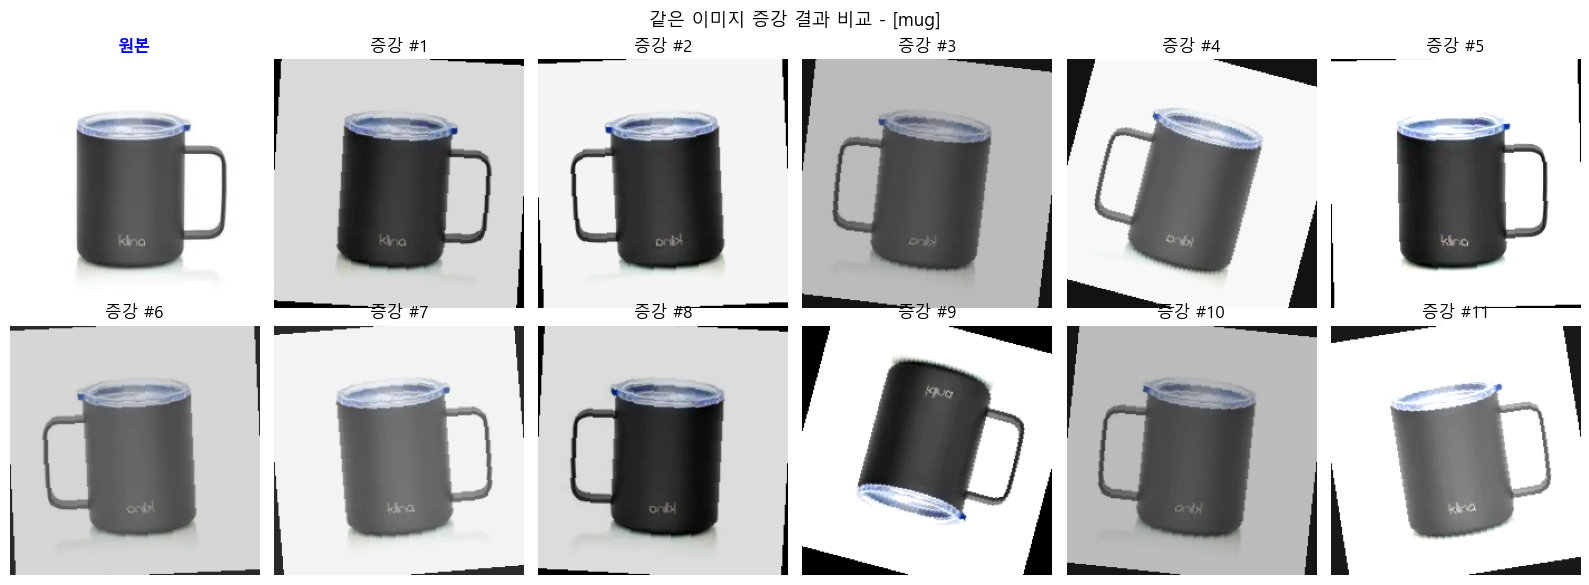

In [3]:
#증강된 이미지 확인
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch

# ── 확인용 transform (증강 적용) ──────────────────────────
check_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
])  # Normalize 제외 → 시각화용

check_dataset = datasets.ImageFolder(root=DATA_DIR, transform=check_transform)

# ── 한 이미지를 여러 번 증강해서 비교 ────────────────────
from PIL import Image

sample_path, sample_label = check_dataset.samples[0]  # 첫 번째 이미지
print(f"원본 이미지: {sample_path}  |  클래스: {CLASSES[sample_label]}")

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle(f"같은 이미지 증강 결과 비교 - [{CLASSES[sample_label]}]", fontsize=13)

# 원본
orig = transforms.ToTensor()(transforms.Resize((224, 224))(Image.open(sample_path).convert('RGB')))
axes[0][0].imshow(orig.permute(1, 2, 0))
axes[0][0].set_title("원본", color='blue', fontweight='bold')
axes[0][0].axis('off')

# 나머지 11장 — 매번 랜덤하게 증강
for i, ax in enumerate(axes.flat):
    if i == 0:
        continue
    img, _ = check_dataset[0]   # 같은 이미지, 매번 다른 증강
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(f"증강 #{i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# ── 전처리 / 증강 정의 ────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ── 전체 데이터셋 로드 (우선 val_transform으로) ──────────
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)

# 클래스 인덱스 확인
print('클래스 → 인덱스:', full_dataset.class_to_idx)
print(f'전체 이미지 수: {len(full_dataset)}')

# ── Train / Val 분할 ──────────────────────────────────────
val_size   = int(len(full_dataset) * VAL_RATIO)
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# train에만 augmentation 적용
train_dataset.dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
# val은 그대로 (val_transform 유지)

print(f'Train: {train_size}장  |  Val: {val_size}장')

# ── DataLoader ────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

클래스 → 인덱스: {'mug': 0, 'straight': 1, 'taper_smooth': 2, 'taper_step': 3}
전체 이미지 수: 700
Train: 560장  |  Val: 140장


## 3. 클래스별 분포 확인

In [ ]:
from collections import Counter

all_labels  = [label for _, label in full_dataset.samples]
train_labels = [all_labels[i] for i in train_dataset.indices]
val_labels   = [all_labels[i] for i in val_dataset.indices]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, labels, title in zip(axes, [train_labels, val_labels], ['Train', 'Val']):
    cnt = Counter(labels)
    ax.bar([CLASSES[k] for k in sorted(cnt)], [cnt[k] for k in sorted(cnt)],
           color=['#4C72B0','#DD8452','#55A868','#C44E52'])
    ax.set_title(f'{title} 클래스 분포')
    ax.set_ylabel('이미지 수')
    for k in sorted(cnt):
        ax.text(list(sorted(cnt)).index(k), cnt[k]+1, str(cnt[k]), ha='center')
plt.tight_layout()
plt.show()

## 4. 샘플 이미지 확인

In [ ]:
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

def denorm(img_tensor):
    return (img_tensor * std[:, None, None] + mean[:, None, None]).clamp(0, 1)

imgs, labels = next(iter(val_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs): break
    ax.imshow(denorm(imgs[i]).permute(1, 2, 0))
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Val 샘플 이미지')
plt.tight_layout()
plt.show()

## 5. 모델 정의 (EfficientNet-B0, Pretrained)

In [ ]:
def build_model(num_classes=4, backbone='efficientnet_b0', freeze_base=False):
    """
    backbone 선택 가능: 'efficientnet_b0', 'resnet50', 'mobilenet_v3_small'
    """
    if backbone == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if freeze_base:
            for p in model.features.parameters():
                p.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    elif backbone == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        if freeze_base:
            for p in model.parameters():
                p.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif backbone == 'mobilenet_v3_small':
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        if freeze_base:
            for p in model.features.parameters():
                p.requires_grad = False
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

    else:
        raise ValueError(f'지원하지 않는 backbone: {backbone}')

    return model

model = build_model(num_classes=NUM_CLASSES, backbone='efficientnet_b0').to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'총 파라미터:     {total_params:,}')
print(f'학습 파라미터:   {trainable_params:,}')

## 6. 손실함수 / 옵티마이저 / 스케줄러

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# CosineAnnealingLR: 학습률을 에폭에 따라 코사인 곡선으로 감소
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f'Optimizer : AdamW (lr={LR}, weight_decay=1e-4)')
print(f'Scheduler : CosineAnnealingLR (T_max={NUM_EPOCHS})')

## 7. 학습 루프

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
    return running_loss / total, correct / total


# ── 학습 실행 ─────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_path = os.path.join(SAVE_DIR, 'best_model.pth')

print(f'{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}  LR')
print('-' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    va_loss, va_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    cur_lr = scheduler.get_last_lr()[0]
    flag = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), best_model_path)
        flag = ' ★ BEST'

    print(f'{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  {va_loss:>8.4f}  {va_acc*100:>6.2f}%  {cur_lr:.2e}{flag}')

print(f'\n최고 Val Accuracy: {best_val_acc*100:.2f}%  →  {best_model_path}')

## 8. 학습 곡선 시각화

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, history['train_loss'], label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, [a*100 for a in history['train_acc']], label='Train Acc')
axes[1].plot(epochs, [a*100 for a in history['val_acc']],   label='Val Acc')
axes[1].set_title('Accuracy 곡선')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'학습 결과 (Best Val Acc: {best_val_acc*100:.2f}%)')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curve.png'), dpi=150)
plt.show()

## 9. 혼동 행렬 (Confusion Matrix)

In [ ]:
# Best 모델 로드
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels.numpy())

cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix (Val Set)')
plt.ylabel('실제 클래스')
plt.xlabel('예측 클래스')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print('\n=== Classification Report ===')
print(classification_report(all_labels_list, all_preds, target_names=CLASSES))

## 10. 오분류 샘플 확인

In [ ]:
model.eval()
wrong_imgs, wrong_preds, wrong_labels_list = [], [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.to(DEVICE))
        preds = outputs.argmax(dim=1).cpu()
        mask = (preds != labels)
        if mask.any():
            wrong_imgs.extend(imgs[mask])
            wrong_preds.extend(preds[mask].numpy())
            wrong_labels_list.extend(labels[mask].numpy())

n_show = min(16, len(wrong_imgs))
if n_show == 0:
    print('오분류 없음! 완벽한 Val 정확도!')
else:
    fig, axes = plt.subplots(2, min(8, n_show), figsize=(16, 4))
    if n_show <= 8:
        axes = [axes]
    for i, ax in enumerate(np.array(axes).flat):
        if i >= n_show: break
        ax.imshow(denorm(wrong_imgs[i]).permute(1, 2, 0))
        ax.set_title(f'예측:{CLASSES[wrong_preds[i]]}\n정답:{CLASSES[wrong_labels_list[i]]}',
                     fontsize=7, color='red')
        ax.axis('off')
    plt.suptitle(f'오분류 샘플 (총 {len(wrong_imgs)}개)')
    plt.tight_layout()
    plt.show()

## 11. 단일 이미지 추론 함수

In [ ]:
from PIL import Image

def predict_image(img_path, model, transform, classes, device):
    """단일 이미지 경로 → 클래스 예측"""
    model.eval()
    img = Image.open(img_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)[0].cpu().numpy()
        pred   = probs.argmax()

    print(f'예측: {classes[pred]}  (확률: {probs[pred]*100:.1f}%)')
    for i, (cls, prob) in enumerate(zip(classes, probs)):
        bar = '█' * int(prob * 30)
        print(f'  {cls:15s} {prob*100:5.1f}%  {bar}')

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f'{classes[pred]}  ({probs[pred]*100:.1f}%)')
    plt.axis('off')
    plt.show()
    return classes[pred], probs

# ── 사용 예시 ─────────────────────────────────────────────
# predict_image('./test3/KakaoTalk_20260916_091413554.jpg',
#               model, val_transform, CLASSES, DEVICE)